# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Supaya grafik tampil rapi
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Dataset: Telco Customer Churn (Kaggle)
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cek tipe data & info umum tiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Cek jumlah nilai kosong (missing value) di tiap kolom
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# TotalCharges seharusnya numerik, tapi tipe datanya masih object (teks).
# Ini biasanya karena ada baris dengan nilai kosong berupa spasi " ".
# Kita cek dulu berapa banyak baris yang bermasalah.
masalah = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]
print("Jumlah baris bermasalah di kolom TotalCharges:", len(masalah))
masalah[["customerID", "tenure", "TotalCharges"]]

Jumlah baris bermasalah di kolom TotalCharges: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


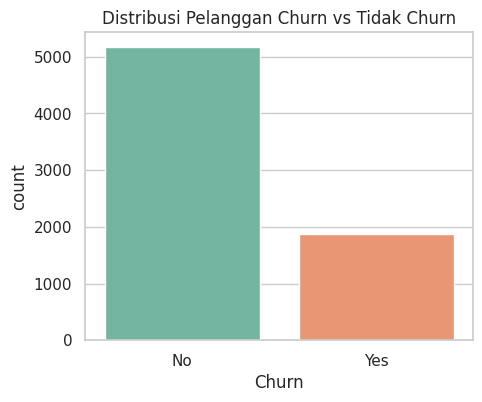

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
# Distribusi target (Churn): berapa persen pelanggan yang berhenti langganan?
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Distribusi Pelanggan Churn vs Tidak Churn")
plt.show()

print(df["Churn"].value_counts(normalize=True) * 100)

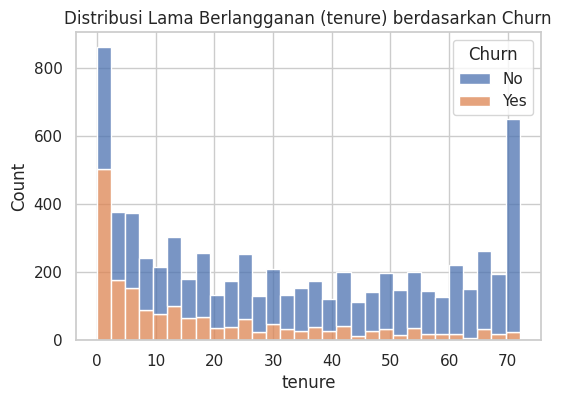

In [8]:
# Cek hubungan antara tenure (lama berlangganan) dengan churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Distribusi Lama Berlangganan (tenure) berdasarkan Churn")
plt.show()

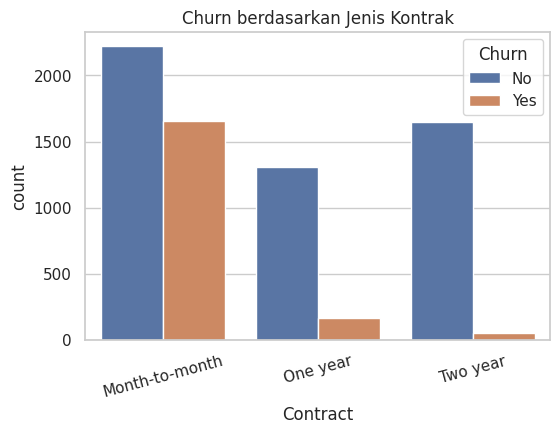

In [9]:
# Cek hubungan antara jenis kontrak dengan churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn berdasarkan Jenis Kontrak")
plt.xticks(rotation=15)
plt.show()

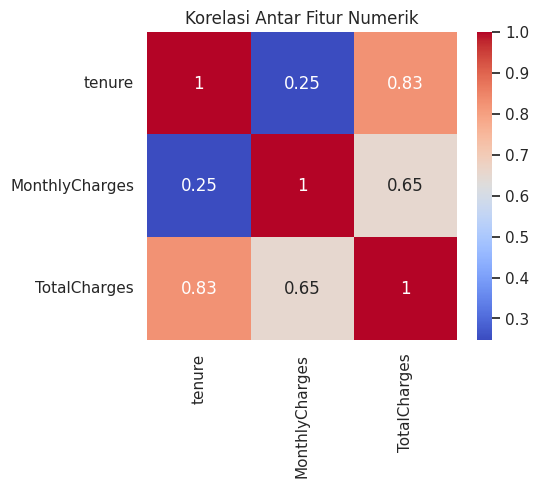

In [10]:
# Korelasi antar kolom numerik
plt.figure(figsize=(5,4))
kolom_numerik = df[["tenure", "MonthlyCharges"]].copy()
kolom_numerik["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
sns.heatmap(kolom_numerik.corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [11]:
# ==============================
# 1. Salin dataset supaya data asli tidak berubah
# ==============================
df_clean = df.copy()

# ==============================
# 2. Menangani Missing Value pada TotalCharges
# ==============================
# Ubah TotalCharges jadi numerik. Baris yang gagal dikonversi otomatis jadi NaN.
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Baris ini biasanya pelanggan baru (tenure = 0), jadi kita isi TotalCharges dengan 0
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

print("Sisa missing value setelah ditangani:")
print(df_clean.isnull().sum().sum())

Sisa missing value setelah ditangani:
0


In [12]:
# ==============================
# 3. Menghapus Data Duplikat (jika ada)
# ==============================
print("Jumlah baris duplikat:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

Jumlah baris duplikat: 0


In [13]:
# ==============================
# 4. Menghapus kolom yang tidak relevan untuk pemodelan
# ==============================
# customerID hanya id unik, tidak punya makna prediktif
df_clean = df_clean.drop(columns=["customerID"])

In [14]:
# ==============================
# 5. Encoding Data Kategorikal
# ==============================
# Ubah kolom target Churn (Yes/No) menjadi angka (1/0)
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Ubah semua kolom kategorikal lain menjadi angka menggunakan Label Encoding
kolom_kategorikal = df_clean.select_dtypes(include="object").columns.tolist()
print("Kolom kategorikal yang akan di-encode:", kolom_kategorikal)

label_encoders = {}
for kolom in kolom_kategorikal:
    le = LabelEncoder()
    df_clean[kolom] = le.fit_transform(df_clean[kolom])
    label_encoders[kolom] = le

df_clean.head()

Kolom kategorikal yang akan di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [15]:
# ==============================
# 6. Normalisasi/Standarisasi Fitur Numerik
# ==============================
kolom_numerik = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()
df_clean[kolom_numerik] = scaler.fit_transform(df_clean[kolom_numerik])

df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.992611,0
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.172165,0
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.958066,1
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.193672,0
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.938874,1


In [16]:
# ==============================
# 7. Split Data menjadi Train dan Test
# ==============================
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran data latih (train):", X_train.shape)
print("Ukuran data uji (test):", X_test.shape)

Ukuran data latih (train): (5634, 19)
Ukuran data uji (test): (1409, 19)


In [17]:
# ==============================
# 8. Menyimpan Dataset Hasil Preprocessing
# ==============================
import os

output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

train_df = X_train.copy()
train_df["Churn"] = y_train
test_df = X_test.copy()
test_df["Churn"] = y_test

train_df.to_csv(f"{output_dir}/train.csv", index=False)
test_df.to_csv(f"{output_dir}/test.csv", index=False)

print("Data hasil preprocessing berhasil disimpan di folder:", output_dir)

Data hasil preprocessing berhasil disimpan di folder: namadataset_preprocessing
